In [15]:
import sys
sys.path.append('..')
import selex_dca, utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import utils
import selex_dca
import selex_distribution, energy_models, tree, data_loading, training, callback, sampling
import diagnostic, specialized_models

from matplotlib import cm
import pickle
import logomaker
import pandas as pd

In [6]:
experiment_id_idx = 1
experiment_ids = ['Dop8V030', 'Dop8V930', 'Dop8V2430']
experiment_id = experiment_ids[experiment_id_idx]
round_ids = ["ARN", "R01", "R02N"]
n_rounds = len(round_ids)
n_selection_rounds = n_rounds - 1

In [3]:
dtype = torch.float32
device = torch.device('cpu')

In [4]:
(sequences, sequences_unique, counts, log_multinomial_factors, 
 sequences_unique_all, counts_unique) = \
    utils.sequences_from_files_detailed(experiment_id, round_ids)

Extracting sequences from 3 files...
Finished round ARN
Finished round R01
Finished round R02N
Merging sequences from all rounds in a single container...
Assigning counts at each round to unique sequences...
	Starting round ARN...
	Starting round R01...
	Starting round R02N...
Finished


In [114]:
sequences_oh = [utils.one_hot(s) for s in sequences]
sequences_unique_all_oh = utils.one_hot(sequences_unique_all)

In [8]:
enrichments = [counts_unique[t+1]/counts_unique[t] for t in range(n_selection_rounds)]

In [35]:
enrichment_longspan = counts_unique[-1] / counts_unique[0]

In [77]:
L, q = sequences_oh[0][0].size()

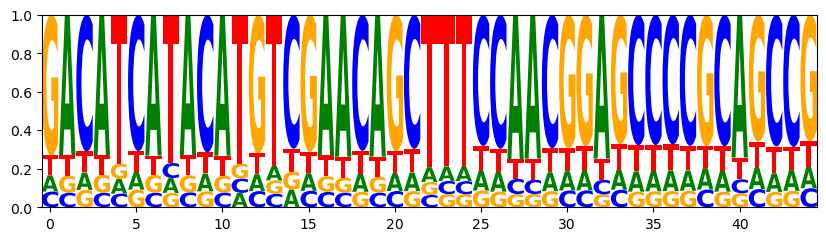

In [23]:
fi_first = utils.get_freq_single_point(sequences_oh[0])
logomaker.Logo(pd.DataFrame(fi_first, columns=list(utils.TOKENS_DNA)));

## Logo at rounds

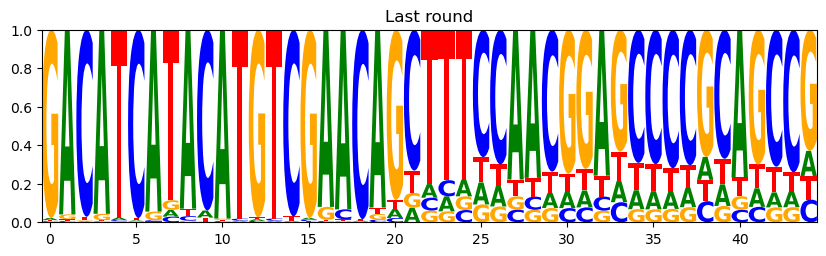

In [33]:
fi_last = utils.get_freq_single_point(sequences_oh[-1])
fig, ax = plt.subplots(figsize=(10,2.5))
ax.set_title('Last round')
logomaker.Logo(pd.DataFrame(fi_last, columns=list(utils.TOKENS_DNA)), ax=ax);

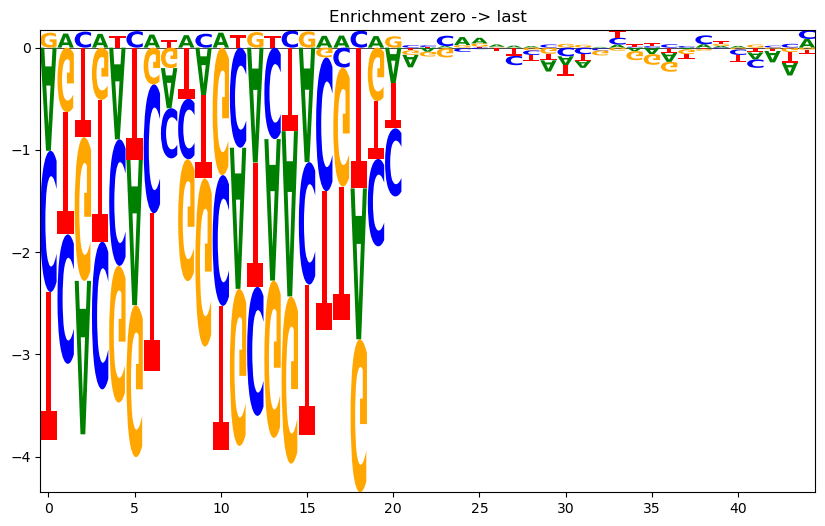

In [34]:
fig, ax = plt.subplots(figsize=(10,6))
ax.set_title('Enrichment zero -> last')
logomaker.Logo(pd.DataFrame(1/n_selection_rounds*torch.log(fi_last / fi_first), columns=list(utils.TOKENS_DNA)), ax=ax)

## Motifs

In [67]:
filepath = './saved/wildtypes_sites.pkl'
with open(filepath, 'rb') as f:
    wts = pickle.load(f)

wt = wts[experiment_id_idx]
wt_oh = utils.one_hot(wt)

In [104]:
motif1 = wt[0:6]
motif2 = wt[10:16]
motifs = torch.stack((motif1, motif2))
motifs_oh = utils.one_hot(motifs)
print(''.join([utils.TOKENS_DNA[a] for a in motif]))

ATGTCG


In [106]:
crosscorr = torch.nn.functional.conv1d(
    sequences_unique_all_oh.transpose(1,2),
    motifs_oh.transpose(1,2)
)

In [246]:
motif_positions = [torch.nonzero(crosscorr[:,m,:] == len(motifs[m])) for m in range(len(motifs))]

Text(0.5, 0, 'Starting site')

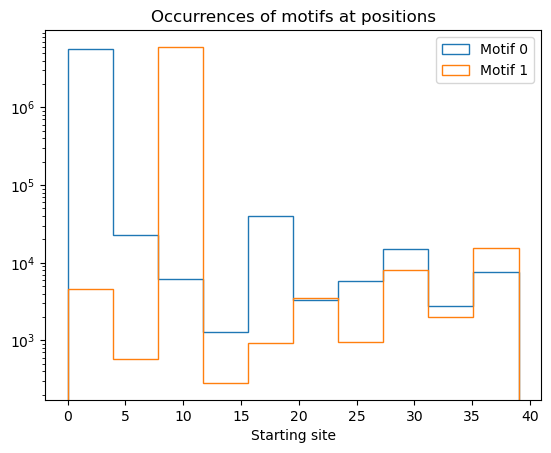

In [260]:
fig, ax = plt.subplots()

for m in range(len(motifs)):
    ax.hist(motif_positions[m][:,1], histtype='step', label=f'Motif {m}')

ax.legend()
ax.set_yscale('log')
ax.set_title('Occurrences of motifs at positions')
ax.set_xlabel('Starting site')

In [172]:
contain_motifs = torch.stack([torch.any(crosscorr[:,m,:] == len(motifs[m]), dim=-1) for m in range(len(motifs))]).T

In [173]:
contain_motifs.size()

torch.Size([15979317, 2])

In [244]:
contain_motifs.to(dtype).mean(dim=0), contain_motifs.to(dtype).prod(dim=1).mean(dim=0)

(tensor([0.3626, 0.3784]), tensor(0.2519))

In [191]:
idx_noninf = ~torch.logical_or(torch.isnan(enrichment_longspan), torch.isinf(enrichment_longspan))
idx_noninf.to(dtype).mean()

tensor(0.5852)

In [192]:
contain_motifs_noninf = torch.logical_and(contain_motifs, idx_noninf.unsqueeze(1))
contain_motifs_noninf.to(dtype).mean(dim=0)

tensor([0.0933, 0.0944])

In [183]:
enrichment_longspan_noninf = enrichment_longspan[idx_noninf]

In [ ]:
enr_min = 

enrichment_longspan_clamped = torch.clamp(enrichment_longspan, enr_min, enr_max)

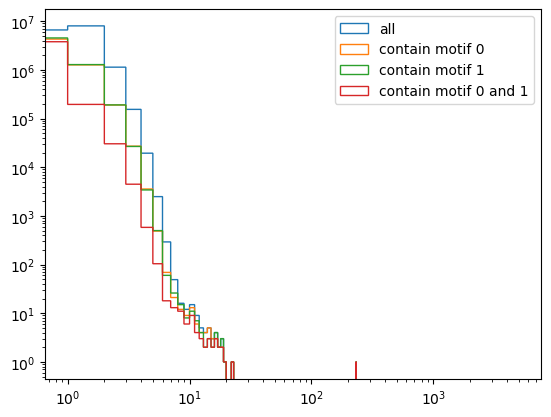

In [237]:
t = 0

fig, ax = plt.subplots()
bins = torch.arange(0, 5000)
ax.hist(counts_unique[t], bins=bins, histtype='step', label='all')
ax.hist(counts_unique[t][contain_motifs[:,0]], bins=bins, histtype='step', label='contain motif 0')
ax.hist(counts_unique[t][contain_motifs[:,1]], bins=bins, histtype='step', label='contain motif 1')
ax.hist(counts_unique[t][torch.logical_and(contain_motifs[:,0], contain_motifs[:,1])], bins=bins, histtype='step', label='contain motif 0 and 1')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

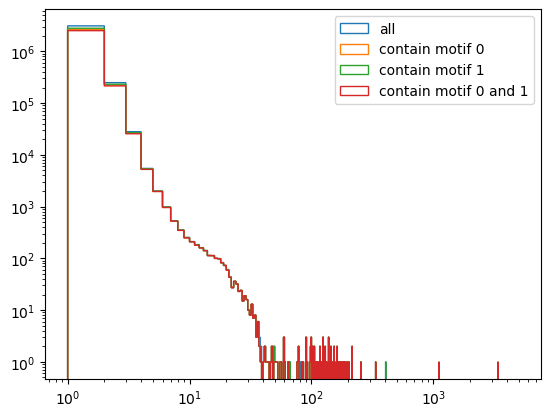

In [240]:
t = 2

fig, ax = plt.subplots()
bins = torch.arange(1, 5000)
ax.hist(counts_unique[t], bins=bins, histtype='step', label='all')
ax.hist(counts_unique[t][contain_motifs[:,0]], bins=bins, histtype='step', label='contain motif 0')
ax.hist(counts_unique[t][contain_motifs[:,1]], bins=bins, histtype='step', label='contain motif 1')
ax.hist(counts_unique[t][torch.logical_and(contain_motifs[:,0], contain_motifs[:,1])], bins=bins, histtype='step', label='contain motif 0 and 1')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

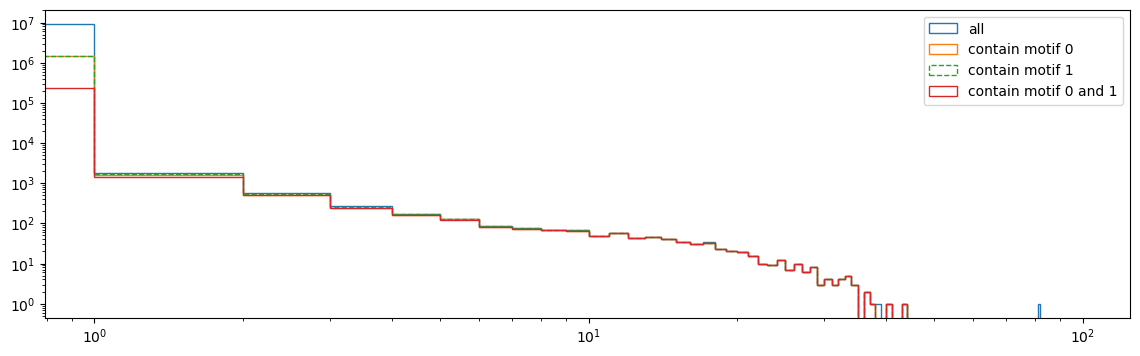

In [243]:
fig, ax = plt.subplots(figsize=(14,4))
bins = torch.logspace(-2, 3, 10)
bins = torch.arange(0, 100)
ax.hist(enrichment_longspan[idx_noninf], bins=bins, histtype='step', label='all')
ax.hist(enrichment_longspan[contain_motifs_noninf[:,0]], bins=bins, histtype='step', label='contain motif 0')
ax.hist(enrichment_longspan[contain_motifs_noninf[:,1]], bins=bins, histtype='step', label='contain motif 1', ls='--')
ax.hist(enrichment_longspan[torch.logical_and(contain_motifs[:,0], contain_motifs[:,1])], bins=bins, histtype='step', label='contain motif 0 and 1')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend();

In [228]:
idx_enriched_no_motif = torch.nonzero(torch.logical_and(idx_noninf, torch.logical_and(~contain_motifs[:,0], enrichment_longspan > 50)))

In [229]:
enrichment_longspan[idx_enriched_no_motif]

tensor([[81.]])

In [230]:
contain_motifs_noninf[idx, 0]

tensor(True)

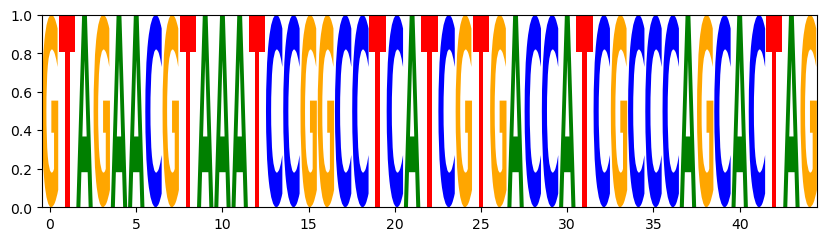

In [231]:
for idx in idx_enriched_no_motif:
    # fig, ax = plt.subplots(figsize=(10,6))
    # ax.set_title('Enrichment zero -> last')
    logomaker.Logo(pd.DataFrame(sequences_unique_all_oh[idx].squeeze(), columns=list(utils.TOKENS_DNA)))

## Enrichment logos

In [59]:
len(sequences_unique_all[idx]), len(enrichment_longspan_clamped)

(12737132, 12737132)

In [62]:
s = sequences_unique_all[idx]
s.size()

torch.Size([12737132, 45])

In [63]:
X = torch.repeat_interleave(s, enrichment_longspan_clamped)

RuntimeError: repeats must have the same size as input along dim, but got repeats.size(0) = 12737132 and input.size(0) = 573170940

In [51]:
logomaker.Logo(pd.DataFrame(utils.get_freq_single_point(enrichment_longspan_clamped), columns=list(utils.TOKENS_DNA)));

RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
RuntimeError: Expected 3 elements in a list but found 1
